# Implementação da Arquitetura LeNet-5

Este notebook contém a implementação da clássica arquitetura LeNet-5 utilizando PyTorch. Esta rede foi proposta por Yann LeCun et al. em 1998 para o reconhecimento de dígitos manuscritos.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # C1: 1 input image channel, 6 output channels, 5x5 square convolution
        # we add padding=2 to handle 28x28 MNIST images like the original 32x32 input
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        # S2: Max pooling layer with 2x2 kernel and stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # C3: 6 input channels, 16 output channels, 5x5 square convolution
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        # S4: Max pooling layer with 2x2 kernel and stride 2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # C5: 16 input channels, 120 output channels, 5x5 square convolution
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)
        # F6: Fully connected layer
        self.fc1 = nn.Linear(120, 84)
        # Output level: Fully connected layer
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        # Apply C1 followed by ReLU activation and S2 pooling
        x = self.pool1(F.relu(self.conv1(x)))
        # Apply C3 followed by ReLU activation and S4 pooling
        x = self.pool2(F.relu(self.conv2(x)))
        # Apply C5 followed by ReLU activation
        x = F.relu(self.conv3(x))
        # Flatten the output for the fully connected layers
        x = x.view(x.size(0), -1)
        # Apply F6 followed by ReLU activation
        x = F.relu(self.fc1(x))
        # Final output layer
        x = self.fc2(x)
        return x

## Visualização dos Filtros (Pesos Iniciais)

Abaixo, instanciamos o modelo e visualizamos os pesos aleatórios da primeira camada convolucional (`conv1`) antes de qualquer treinamento.

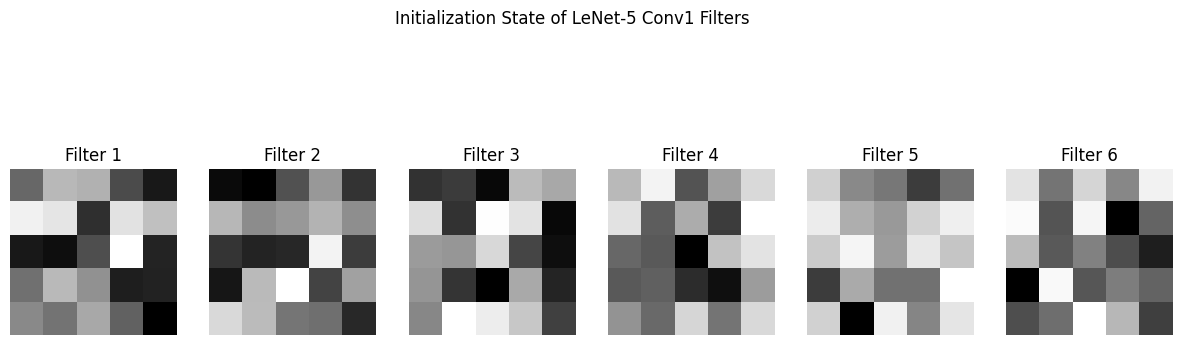

In [2]:
import matplotlib.pyplot as plt

# Instantiate the model
model = LeNet5(num_classes=10)

# Extract filters from the first convolutional layer
filters = model.conv1.weight.detach()

# Plotting the filters
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    # Standard convolution filters have depth (channels); we take the first slice
    # Since MNIST is grayscale, input_channels = 1
    ax.imshow(filters[i, 0], cmap='gray')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')

plt.suptitle('Initialization State of LeNet-5 Conv1 Filters')
plt.show()